In [16]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format="retina"

In [17]:
def p(x):
    # return norm.pdf(x, loc=30, scale=10) + norm.pdf(x, loc=80, scale=20)
    return norm.pdf(x, loc=45, scale=30)

def q(x):
    return norm.pdf(x, loc=50, scale=30)

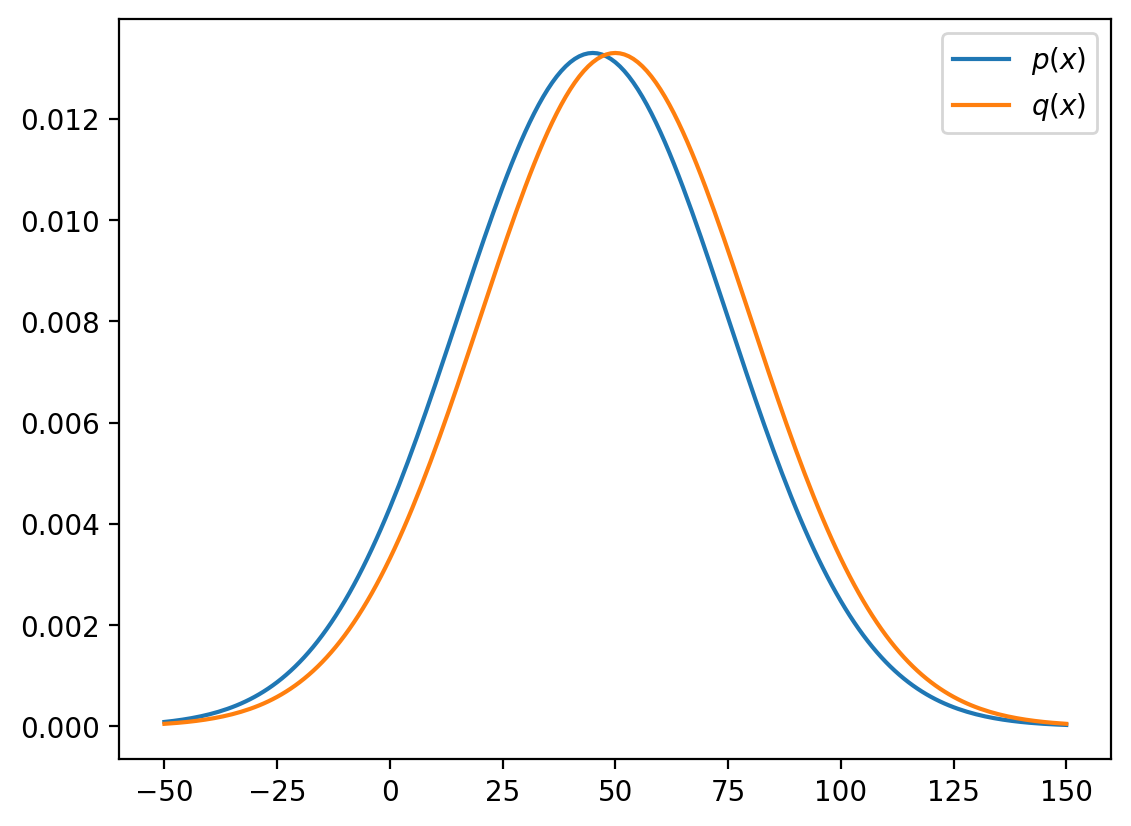

In [18]:
x = np.arange(-50, 151)
fig, ax = plt.subplots()
ax.plot(x, p(x), label=r"$p(x)$")
ax.plot(x, q(x), label=r"$q(x)$")
plt.legend()
plt.show()

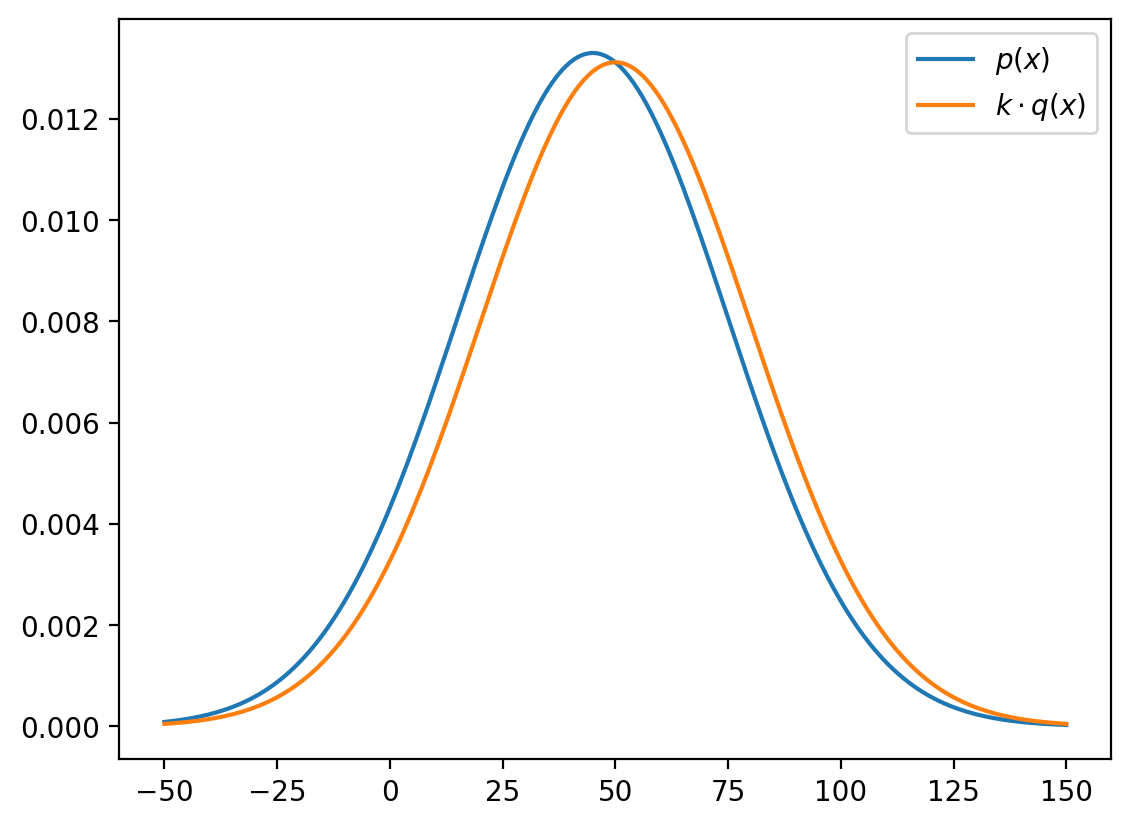

In [19]:
k = np.median(p(x) / q(x))

fig, ax = plt.subplots()
ax.plot(x, p(x), label=r"$p(x)$")
ax.plot(x, k * q(x), label=r"$k \cdot q(x)$")
plt.legend()
plt.show()

mask percentage:  0.9609375


/tmp/ipykernel_10998/1493679851.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(samples)


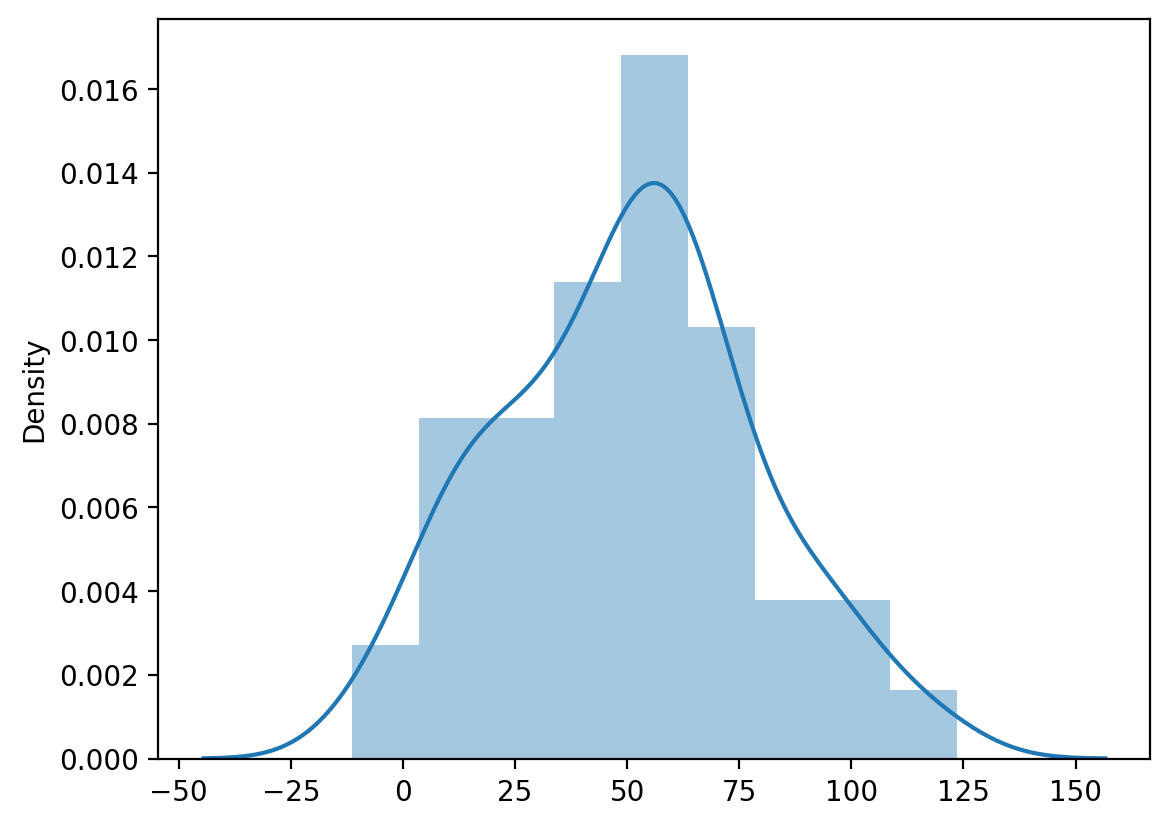

In [20]:
def sample(size):
    xs = np.random.normal(50, 30, size=size)
    cs = np.random.uniform(0, 1, size=size)
    mask = p(xs) / (k * q(xs)) > cs
    return xs[mask], np.mean(mask)

def sample_clipped(size):
    xs = np.random.normal(50, 30, size=size)
    ratios = p(xs) / q(xs)
    mask = (ratios < 1.5) & (ratios > 0.5)
    return xs[mask] 

samples, percentage = sample(128)
sns.distplot(samples)
print('mask percentage: ', percentage)
plt.show()